In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from google.colab import files
uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore (1).csv


In [7]:
import pandas as pd

data = pd.read_csv("/content/SampleSuperstore.csv")
data.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [8]:
print("\nDataset Link: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final")
print("\nColumn Descriptions:")
print("""
- Ship Mode: Method of shipping (e.g., Standard Class, Second Class)
- Segment: Customer segment (Consumer, Corporate, Home Office)
- Country: Country of the transaction (usually United States)
- City: City of the transaction
- State: State/Region of the transaction
- Postal Code: Postal code
- Region: Geographic region (West, East, Central, South)
- Category: Product category (Furniture, Office Supplies, Technology)
- Sub-Category: Product sub-category
- Sales: Sales amount
- Quantity: Number of items sold
- Discount: Discount percentage applied
- Profit: Profit from the transaction
""")



Dataset Link: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

Column Descriptions:

- Ship Mode: Method of shipping (e.g., Standard Class, Second Class)
- Segment: Customer segment (Consumer, Corporate, Home Office)
- Country: Country of the transaction (usually United States)
- City: City of the transaction
- State: State/Region of the transaction
- Postal Code: Postal code
- Region: Geographic region (West, East, Central, South)
- Category: Product category (Furniture, Office Supplies, Technology)
- Sub-Category: Product sub-category
- Sales: Sales amount
- Quantity: Number of items sold
- Discount: Discount percentage applied
- Profit: Profit from the transaction



In [9]:
data.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [11]:
sales_data = data[['Discount','Profit']]
sales_data.head()

,Discount,Profit
0,0.00,41.9136
1,0.00,219.5820
2,0.00,6.8714
3,0.45,-383.0310
4,0.20,2.5164


In [12]:
sales_data.describe()

,Discount,Profit
count,9994.000000,9994.000000
mean,0.156203,28.656896
std,0.206452,234.260108
min,0.000000,-6599.978000
25%,0.000000,1.728750
50%,0.200000,8.666500
75%,0.200000,29.364000
max,0.800000,8399.976000


In [13]:
correlation = sales_data.corr()
print(correlation)

          Discount    Profit
Discount  1.000000 -0.219487
Profit   -0.219487  1.000000


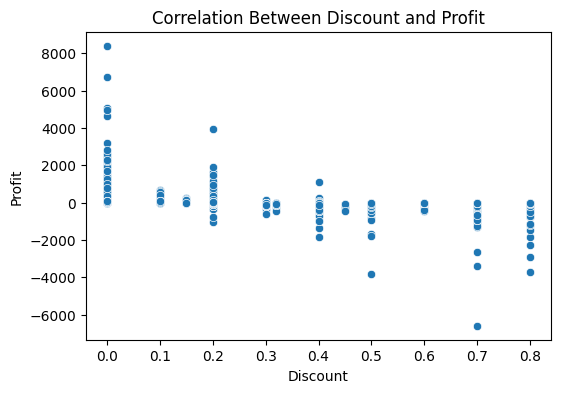

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Discount', y='Profit', data=sales_data)

plt.title("Correlation Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

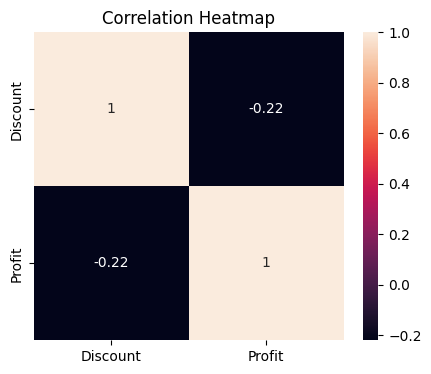

In [15]:
plt.figure(figsize=(5,4))
sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
corr_value = sales_data['Discount'].corr(sales_data['Profit'])

print("Correlation value:", corr_value)

if corr_value < 0:
    print("There is a negative correlation between Discount and Profit.")
else:
        print("There is a positive correlation between Discount and Profit.")


Correlation value: -0.21948745637176803
There is a negative correlation between Discount and Profit.


In [17]:
if corr_value < 0:
    print("There is a negative correlation between Discount and Profit.")
else:
    print("There is a positive correlation between Discount and Profit.")


There is a negative correlation between Discount and Profit.


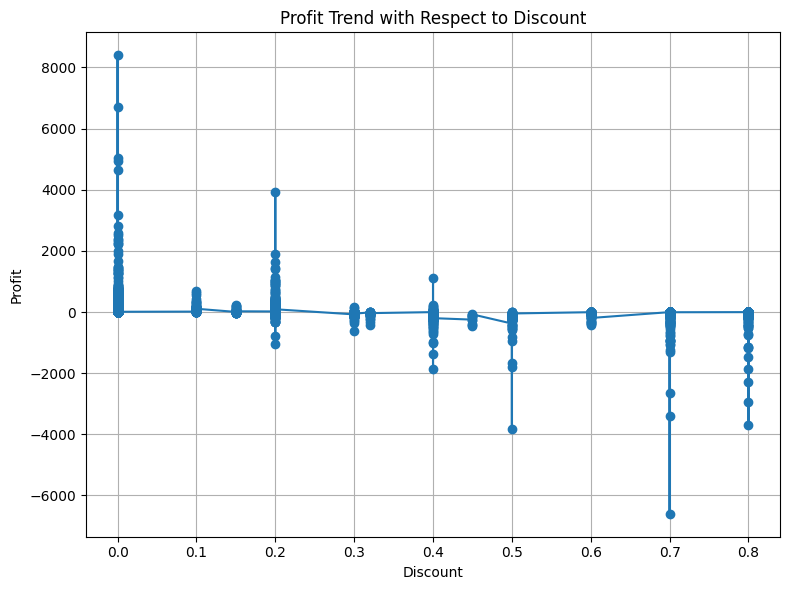

In [18]:

sorted_data = sales_data.sort_values(by='Discount')

plt.figure(figsize=(8, 6))
plt.plot(sorted_data['Discount'], sorted_data['Profit'], marker='o', linestyle='-')
plt.title("Profit Trend with Respect to Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

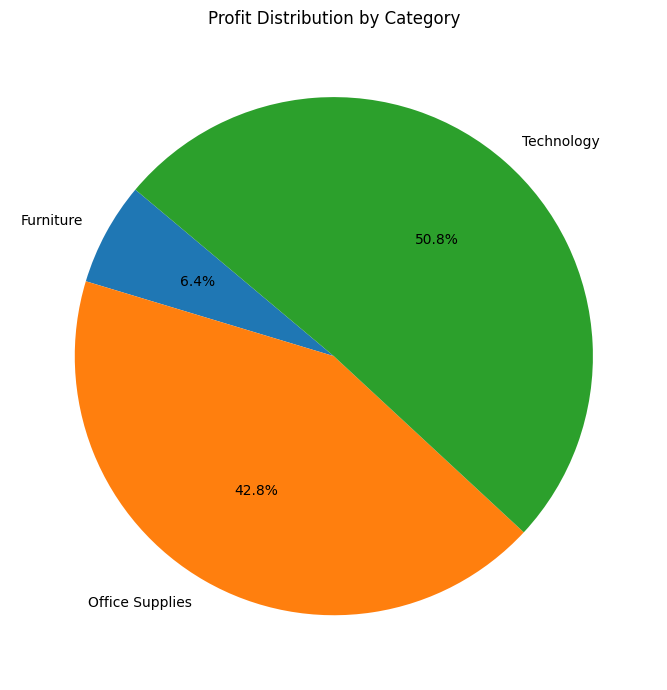

In [23]:

category_profit = data.groupby('Category')['Profit'].sum()

plt.figure(figsize=(7, 7))
plt.pie(category_profit, labels=category_profit.index, autopct='%1.1f%%', startangle=140)
plt.title("Profit Distribution by Category")
plt.tight_layout()
plt.show()

In [24]:

total_profit = data['Profit'].sum()
total_sales = data['Sales'].sum()

profit_margin = (total_profit / total_sales) * 100
print("Profit Margin:", round(profit_margin, 2), "%")

Profit Margin: 12.47 %
